In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')

In [5]:
df = pd.read_csv('datathon_2026_round1/dataset/interim/csv_exports/web_traffic_base.csv')

In [8]:
df.dtypes

date                        datetime64[ns]
sessions                             int64
unique_visitors                      int64
page_views                           int64
bounce_rate                        float64
avg_session_duration_sec           float64
traffic_source                      object
dtype: object

In [7]:
df['date'] = pd.to_datetime(df['date'])

In [9]:
df

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral
...,...,...,...,...,...,...,...
3647,2022-12-27,17416,13150,62527,0.00506,252.4,organic_search
3648,2022-12-28,21071,15979,67456,0.00560,177.3,organic_search
3649,2022-12-29,20884,14640,82155,0.00522,165.6,direct
3650,2022-12-30,17679,13713,79308,0.00350,183.8,email_campaign


In [10]:
sessions_daily = (
    df
    .groupby('date')['sessions']
    .sum()
    .reset_index()
)

In [12]:
sessions_daily

,date,sessions
0,2013-01-01,9760
1,2013-01-02,10456
2,2013-01-03,10076
3,2013-01-04,9973
4,2013-01-05,10223
...,...,...
3647,2022-12-27,17416
3648,2022-12-28,21071
3649,2022-12-29,20884
3650,2022-12-30,17679


In [15]:
sales = pd.read_csv('datathon_2026_round1/dataset/interim/csv_exports/sales_base.csv')

In [17]:
sales['date'] = pd.to_datetime(sales['date'])

In [18]:
merge = sales.merge(
    sessions_daily,
    left_on='date',
    right_on='date',
    how='left'
)

In [19]:
merge

,date,revenue,cogs,sessions
0,2012-07-04,5123547.94,3982991.19,NaN
1,2012-07-05,2751773.45,2150580.23,NaN
2,2012-07-06,3054029.42,2517632.84,NaN
3,2012-07-07,2667930.94,2108246.62,NaN
4,2012-07-08,2360851.90,1808622.79,NaN
...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,17416.0
3829,2022-12-28,3448729.20,3513621.00,21071.0
3830,2022-12-29,3083944.33,3170787.10,20884.0
3831,2022-12-30,2884668.76,3022292.15,17679.0


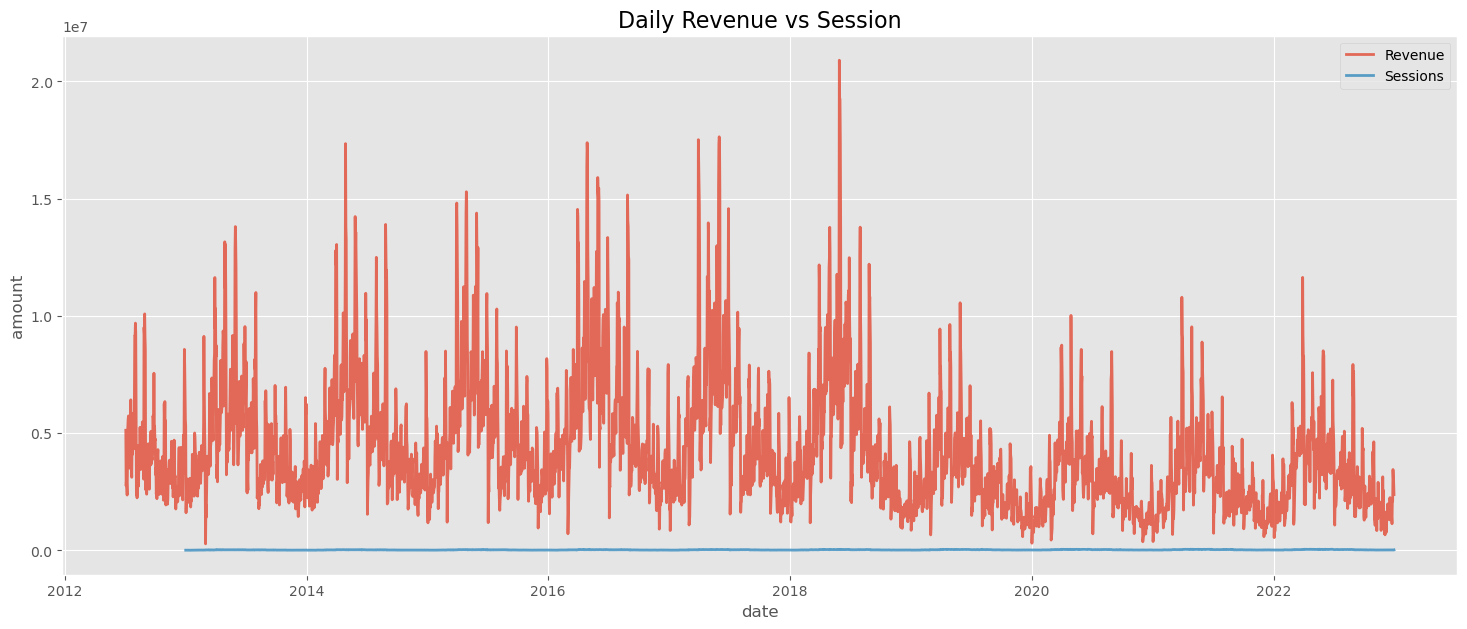

In [20]:
plt.figure(figsize=(18,7))

plt.plot(
    merge['date'],
    merge['revenue'],
    linewidth=2,
    alpha=0.8,
    label='Revenue'
)

plt.plot(
    merge['date'],
    merge['sessions'],
    linewidth=2,
    alpha=0.8,
    label='Sessions'
)

plt.title('Daily Revenue vs Session', fontsize=16)

plt.xlabel('date')
plt.ylabel('amount')

plt.legend()

plt.grid(True)
plt.savefig(
    'chart2_1.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [22]:
sales['date'].min(), sales['date'].max()

(Timestamp('2012-07-04 00:00:00'), Timestamp('2022-12-31 00:00:00'))

In [23]:
sessions_daily['date'].min(), sessions_daily['date'].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2022-12-31 00:00:00'))

In [24]:
merge['sessions'].isna().sum()

np.int64(181)

In [25]:
merge[merge['sessions'].isna()]

,date,revenue,cogs,sessions
0,2012-07-04,5123547.94,3982991.19,NaN
1,2012-07-05,2751773.45,2150580.23,NaN
2,2012-07-06,3054029.42,2517632.84,NaN
3,2012-07-07,2667930.94,2108246.62,NaN
4,2012-07-08,2360851.90,1808622.79,NaN
...,...,...,...,...
176,2012-12-27,4994041.71,3924374.73,NaN
177,2012-12-28,8573663.31,6682336.48,NaN
178,2012-12-29,7842913.37,6260959.87,NaN
179,2012-12-30,6511908.92,5180121.12,NaN


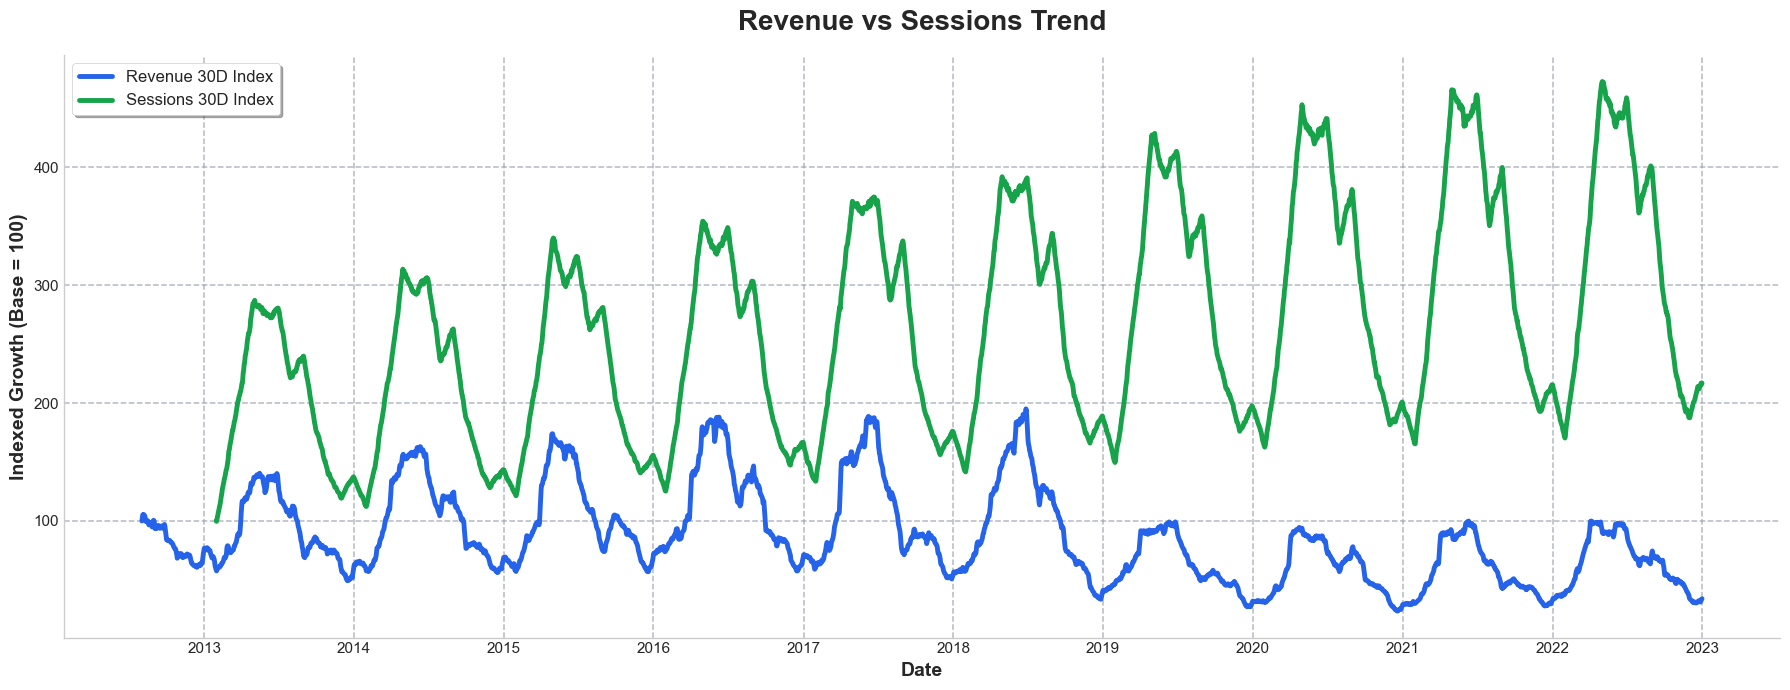

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================================================
# SORT DATA
# =========================================================

merge = merge.sort_values('date').copy()

merge['date'] = pd.to_datetime(
    merge['date'],
    errors='coerce'
)

# =========================================================
# ROLLING FEATURES
# =========================================================

merge['Revenue_30D'] = (
    merge['revenue']
    .rolling(30)
    .mean()
)

merge['Sessions_30D'] = (
    merge['sessions']
    .rolling(30)
    .mean()
)

# =========================================================
# INDEX NORMALIZATION
# Dùng first valid value để tránh NaN ở đầu kỳ
# =========================================================

revenue_base = merge['Revenue_30D'].dropna().iloc[0]
sessions_base = merge['Sessions_30D'].dropna().iloc[0]

merge['Revenue_Index'] = (
    merge['Revenue_30D'] / revenue_base
) * 100

merge['Sessions_Index'] = (
    merge['Sessions_30D'] / sessions_base
) * 100

# =========================================================
# STYLE
# =========================================================

plt.style.use('seaborn-v0_8-whitegrid')

# =========================================================
# CREATE FIGURE
# =========================================================

fig, ax = plt.subplots(
    figsize=(18,7)
)

fig.patch.set_facecolor('white')

# =========================================================
# LINE CHART
# =========================================================

ax.plot(
    merge['date'],
    merge['Revenue_Index'],
    linewidth=3.5,
    label='Revenue 30D Index',
    color='#2563eb'
)

ax.plot(
    merge['date'],
    merge['Sessions_Index'],
    linewidth=3.5,
    label='Sessions 30D Index',
    color='#16a34a'
)

# =========================================================
# TITLES
# =========================================================

ax.set_title(
    'Revenue vs Sessions Trend',
    fontsize=20,
    fontweight='bold',
    pad=18
)

ax.set_xlabel(
    'Date',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    'Indexed Growth (Base = 100)',
    fontsize=14,
    fontweight='bold'
)

# =========================================================
# LEGEND
# =========================================================

ax.legend(
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True
)

# =========================================================
# GRID
# =========================================================

ax.set_axisbelow(True)

ax.grid(
    True,
    linestyle='--',
    linewidth=1.1,
    alpha=0.75,
    color='#9ca3af'
)

# =========================================================
# REMOVE BORDER
# =========================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# =========================================================
# TICK FORMAT
# =========================================================

ax.tick_params(
    axis='x',
    labelsize=11
)

ax.tick_params(
    axis='y',
    labelsize=11
)

# =========================================================
# DATE FORMAT
# =========================================================

ax.xaxis.set_major_locator(
    mdates.YearLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)

# =========================================================
# LAYOUT + SAVE
# =========================================================

plt.tight_layout()

plt.savefig(
    'revenue_sessions_index_30d.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()